In [1]:
import tensorflow as tf
from keras.models import Model, Sequential
from keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from keras.callbacks import EarlyStopping
from keras.layers.core import SpatialDropout2D
from keras import backend as K
from tensorflow.keras.optimizers import Adam, RMSprop
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
%matplotlib inline
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout
 
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
from keras.models import load_model
import itertools 
import random
filterwarnings('ignore')
random.seed(0)
np.random.seed(0)
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.mixed_precision import experimental as mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

In [2]:
import tensorflow as tf
import numpy as np
import os
import random


def set_seed(seed):
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)


seed = 101
set_seed(seed)

In [3]:
train_dir = "train"
test_dir = "test"
val_dir= "val"


In [4]:
model1 = EfficientNetV2B0(include_top=False,input_shape=(224, 224,3), weights='imagenet')
input_shape = (224, 224)

In [5]:
datagen_train = ImageDataGenerator(rescale=1./255,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  horizontal_flip=True,
                                  vertical_flip=False)



datagen_test = ImageDataGenerator(rescale=1./255)

datagen_val=ImageDataGenerator(rescale=1./255)

batch_size = 20
generator_train = datagen_train.flow_from_directory(directory=train_dir,
                                                    target_size=input_shape,
                                                    batch_size=batch_size,  
                                                    class_mode='categorical',
                                                    shuffle=True)

generator_val = datagen_val.flow_from_directory(directory=val_dir,
                                                  target_size=input_shape,
                                                  batch_size=batch_size,
                                                class_mode='categorical',
                                                  shuffle=True)
generator_test=datagen_test.flow_from_directory(directory=test_dir,
                                                  target_size=input_shape,
                                                 batch_size=batch_size,
                                                class_mode='categorical',
                                                 shuffle=False)

Found 3248 images belonging to 4 classes.
Found 409 images belonging to 4 classes.
Found 405 images belonging to 4 classes.


In [6]:
len(model1.layers)

270

In [7]:
def print_layer_trainable():
    for layer in model1.layers[4:70]:
        layer.trainable=False
        print("{0}:\t{1}".format(layer.trainable, layer.name))


print_layer_trainable()

False:	stem_bn
False:	stem_activation
False:	block1a_project_conv
False:	block1a_project_bn
False:	block1a_project_activation
False:	block2a_expand_conv
False:	block2a_expand_bn
False:	block2a_expand_activation
False:	block2a_project_conv
False:	block2a_project_bn
False:	block2b_expand_conv
False:	block2b_expand_bn
False:	block2b_expand_activation
False:	block2b_project_conv
False:	block2b_project_bn
False:	block2b_drop
False:	block2b_add
False:	block3a_expand_conv
False:	block3a_expand_bn
False:	block3a_expand_activation
False:	block3a_project_conv
False:	block3a_project_bn
False:	block3b_expand_conv
False:	block3b_expand_bn
False:	block3b_expand_activation
False:	block3b_project_conv
False:	block3b_project_bn
False:	block3b_drop
False:	block3b_add
False:	block4a_expand_conv
False:	block4a_expand_bn
False:	block4a_expand_activation
False:	block4a_dwconv2
False:	block4a_bn
False:	block4a_activation
False:	block4a_se_squeeze
False:	block4a_se_reshape
False:	block4a_se_reduce
False:	bloc

In [8]:
headModel = model1.output
headModel = layers.Flatten()(headModel)
# headModel = Dense(1024, activation="relu")(headModel)
headModel = Dense(512, activation="relu")(headModel)
headModel = Dropout(.4)(headModel)
headModel = Dense(4, activation="softmax")(headModel)
model = Model(inputs=model1.input, outputs=headModel)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  0           ['rescaling[0][0]']              
                                                                                                  
 stem_conv (Conv2D)             (None, 112, 112, 32  864         ['normalization[0][0]']      

                                                                                                  
 block3b_project_conv (Conv2D)  (None, 28, 28, 48)   9216        ['block3b_expand_activation[0][0]
                                                                 ']                               
                                                                                                  
 block3b_project_bn (BatchNorma  (None, 28, 28, 48)  192         ['block3b_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block3b_drop (Dropout)         (None, 28, 28, 48)   0           ['block3b_project_bn[0][0]']     
                                                                                                  
 block3b_add (Add)              (None, 28, 28, 48)   0           ['block3b_drop[0][0]',           
          

                                                                  'block4a_project_bn[0][0]']     
                                                                                                  
 block4c_expand_conv (Conv2D)   (None, 14, 14, 384)  36864       ['block4b_add[0][0]']            
                                                                                                  
 block4c_expand_bn (BatchNormal  (None, 14, 14, 384)  1536       ['block4c_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block4c_expand_activation (Act  (None, 14, 14, 384)  0          ['block4c_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block4c_d

 block5b_dwconv2 (DepthwiseConv  (None, 14, 14, 672)  6048       ['block5b_expand_activation[0][0]
 2D)                                                             ']                               
                                                                                                  
 block5b_bn (BatchNormalization  (None, 14, 14, 672)  2688       ['block5b_dwconv2[0][0]']        
 )                                                                                                
                                                                                                  
 block5b_activation (Activation  (None, 14, 14, 672)  0          ['block5b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block5b_se_squeeze (GlobalAver  (None, 672)         0           ['block5b_activation[0][0]']     
 agePoolin

                                                                                                  
 block5d_activation (Activation  (None, 14, 14, 672)  0          ['block5d_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block5d_se_squeeze (GlobalAver  (None, 672)         0           ['block5d_activation[0][0]']     
 agePooling2D)                                                                                    
                                                                                                  
 block5d_se_reshape (Reshape)   (None, 1, 1, 672)    0           ['block5d_se_squeeze[0][0]']     
                                                                                                  
 block5d_se_reduce (Conv2D)     (None, 1, 1, 28)     18844       ['block5d_se_reshape[0][0]']     
          

 agePooling2D)                                                                                    
                                                                                                  
 block6a_se_reshape (Reshape)   (None, 1, 1, 672)    0           ['block6a_se_squeeze[0][0]']     
                                                                                                  
 block6a_se_reduce (Conv2D)     (None, 1, 1, 28)     18844       ['block6a_se_reshape[0][0]']     
                                                                                                  
 block6a_se_expand (Conv2D)     (None, 1, 1, 672)    19488       ['block6a_se_reduce[0][0]']      
                                                                                                  
 block6a_se_excite (Multiply)   (None, 7, 7, 672)    0           ['block6a_activation[0][0]',     
                                                                  'block6a_se_expand[0][0]']      
          

                                                                                                  
 block6c_project_conv (Conv2D)  (None, 7, 7, 192)    221184      ['block6c_se_excite[0][0]']      
                                                                                                  
 block6c_project_bn (BatchNorma  (None, 7, 7, 192)   768         ['block6c_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block6c_drop (Dropout)         (None, 7, 7, 192)    0           ['block6c_project_bn[0][0]']     
                                                                                                  
 block6c_add (Add)              (None, 7, 7, 192)    0           ['block6c_drop[0][0]',           
                                                                  'block6b_add[0][0]']            
          

                                                                                                  
 block6e_drop (Dropout)         (None, 7, 7, 192)    0           ['block6e_project_bn[0][0]']     
                                                                                                  
 block6e_add (Add)              (None, 7, 7, 192)    0           ['block6e_drop[0][0]',           
                                                                  'block6d_add[0][0]']            
                                                                                                  
 block6f_expand_conv (Conv2D)   (None, 7, 7, 1152)   221184      ['block6e_add[0][0]']            
                                                                                                  
 block6f_expand_bn (BatchNormal  (None, 7, 7, 1152)  4608        ['block6f_expand_conv[0][0]']    
 ization)                                                                                         
          

                                                                                                  
 block6h_expand_conv (Conv2D)   (None, 7, 7, 1152)   221184      ['block6g_add[0][0]']            
                                                                                                  
 block6h_expand_bn (BatchNormal  (None, 7, 7, 1152)  4608        ['block6h_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block6h_expand_activation (Act  (None, 7, 7, 1152)  0           ['block6h_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block6h_dwconv2 (DepthwiseConv  (None, 7, 7, 1152)  10368       ['block6h_expand_activation[0][0]
 2D)      

In [9]:
len(model.layers)

274

In [10]:
optimizer = Adam(lr=1e-4)
# optimizer = RMSprop(lr=0.00001, rho=0.9, epsilon=1e-08, decay=0.0)
loss = 'categorical_crossentropy'
metrics = ['accuracy','Precision','Recall']


model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

epochs =25

steps_per_epoch = generator_train.n / batch_size
steps_test = generator_test.n / batch_size

# steps_per_epoch = 20
# steps_test = 30
early_stop = EarlyStopping(patience=3)
history = model.fit_generator(generator=generator_train,
                              epochs=epochs,
                              steps_per_epoch=steps_per_epoch,
                              validation_data=generator_val,
                              validation_steps=steps_test
                             
                             )


Epoch 1/25
162/162 [==============================] - 31s 138ms/step - loss: 1.2545 - accuracy: 0.4969 - precision: 0.5516 - recall: 0.3618 - val_loss: 0.6379 - val_accuracy: 0.7848 - val_precision: 0.8196 - val_recall: 0.6553
Epoch 2/25
162/162 [==============================] - 22s 133ms/step - loss: 0.7511 - accuracy: 0.6841 - precision: 0.7578 - recall: 0.5964 - val_loss: 0.8338 - val_accuracy: 0.6137 - val_precision: 0.6144 - val_recall: 0.6039
Epoch 3/25
162/162 [==============================] - 22s 133ms/step - loss: 0.5839 - accuracy: 0.7522 - precision: 0.8397 - recall: 0.6933 - val_loss: 0.2527 - val_accuracy: 0.9169 - val_precision: 0.9342 - val_recall: 0.9022
Epoch 4/25
162/162 [==============================] - 21s 132ms/step - loss: 0.4783 - accuracy: 0.7968 - precision: 0.8745 - recall: 0.7426 - val_loss: 6.1499 - val_accuracy: 0.2689 - val_precision: 0.2689 - val_recall: 0.2689
Epoch 5/25
162/162 [==============================] - 22s 133ms/step - loss: 0.4062 - accura

In [12]:
model.save("EfficientNetV2B0.h5")

In [13]:
#Get the accuracy score

train_score = model.evaluate_generator(generator_train)



print("[INFO] accuracy: {:.2f}%".format(train_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(train_score[0] * 100)) 

[INFO] accuracy: 96.71%
[INFO] Loss: 9.12%


In [14]:
#Get the accuracy score

test_score = model.evaluate_generator(generator_test)



print("[INFO] accuracy: {:.2f}%".format(test_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(test_score[0] * 100)) 

[INFO] accuracy: 96.05%
[INFO] Loss: 12.56%


In [15]:

classes=list(generator_train.class_indices.keys())
class_count=len(classes)
print(class_count)
print(classes)
li=['1','2','3','4']

4
['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


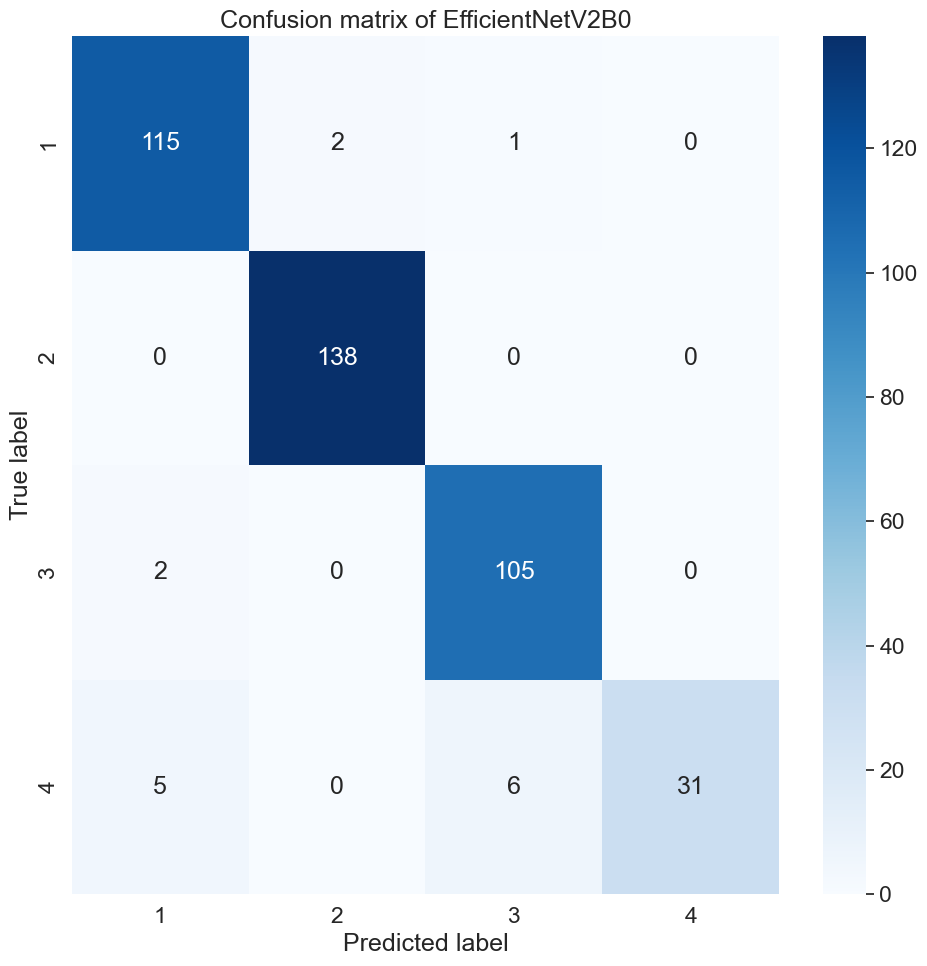

In [16]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
Y_pred = model.predict_generator(generator_test)
y_pred = np.argmax(Y_pred, axis=1)
array = confusion_matrix(generator_test.classes, y_pred)
df_cm = pd.DataFrame(array, index =li,
                  columns = li)
plt.figure(figsize=(10,10))
sn.set(font_scale=1.5)
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix of EfficientNetV2B0')
plt.tight_layout()
plt.savefig('EfficientNetV2B0_confusion',dpi=200); 
plt.show()



In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(generator_test.classes, y_pred)

0.9604938271604938

In [18]:
target_names = []

for key in generator_train.class_indices:

    target_names.append(key)



print(target_names)

['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


In [19]:
print(classification_report(generator_test.classes, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       118
           1       0.99      1.00      0.99       138
           2       0.94      0.98      0.96       107
           3       1.00      0.74      0.85        42

    accuracy                           0.96       405
   macro avg       0.97      0.92      0.94       405
weighted avg       0.96      0.96      0.96       405



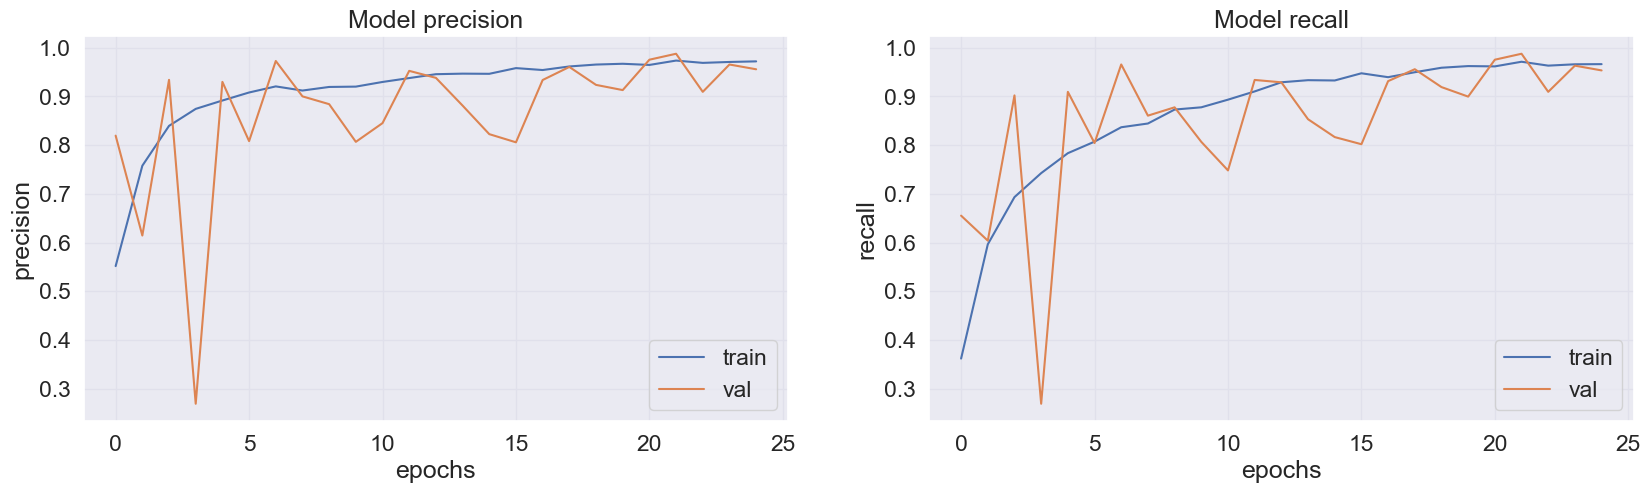

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'])
plt.show()

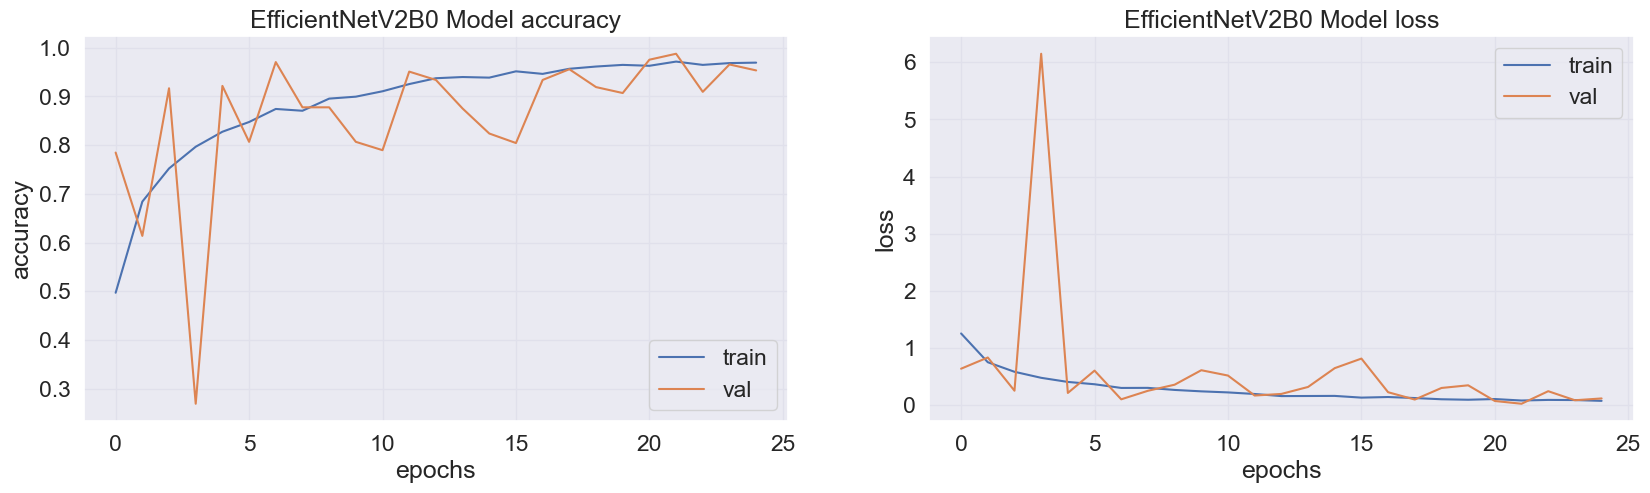

In [21]:

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()
for i, met in enumerate([ 'accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('EfficientNetV2B0 Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'],loc='best')
plt.show()

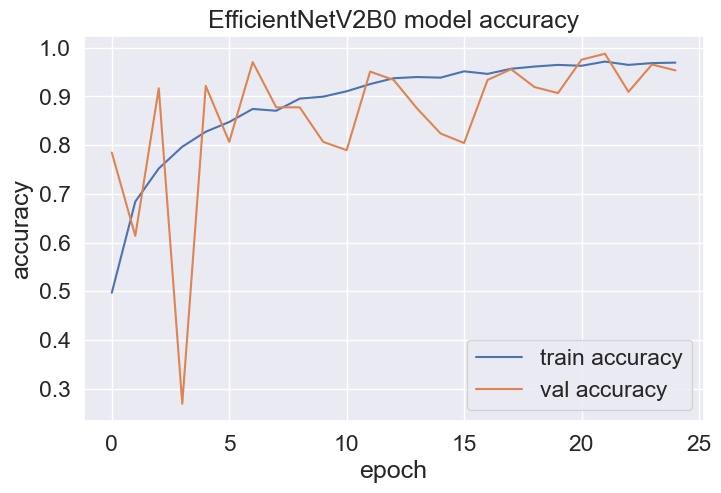

In [22]:

plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['accuracy'],label="train accuracy")
plt.plot(history.history['val_accuracy'],label="val accuracy")
plt.title('EfficientNetV2B0 model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('EfficientNetV2B0_accuracy',dpi=200); 
plt.show()


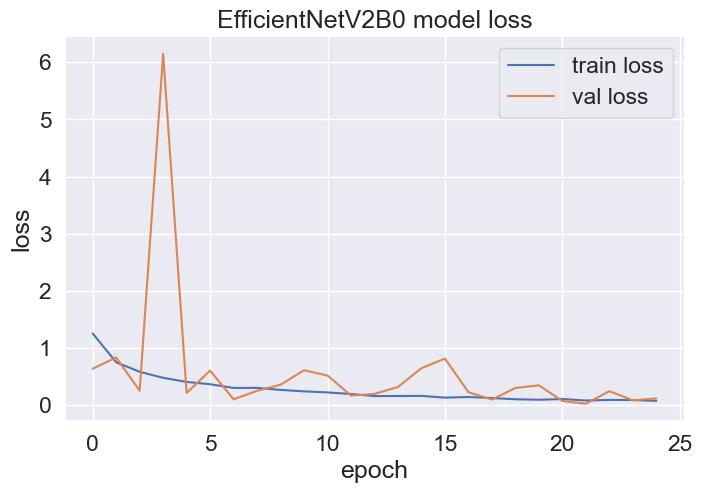

In [23]:
plt.figure(figsize=(8, 5))

ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['loss'],label="train loss")
plt.plot(history.history['val_loss'],label="val loss")
plt.title('EfficientNetV2B0 model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('EfficientNetV2B0_loss',dpi=200); 
plt.show()